# Week 10 Bonus: Neural Cleanse Implementation

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from utils_week9to11 import LeNet5, train, test

# 实验参数
batch_size = 128
epochs = 10
lr = 0.01
device = 'cuda' if torch.cuda.is_available() else 'cpu'


## 1. 数据集准备
使用和投毒时相同的遍历方式获取10%的干净训练数据集。

In [2]:
simple_transform = torchvision.transforms.ToTensor()
# 获取完整的干净训练集
clean_train_data = torchvision.datasets.MNIST(root='data/', train=True, transform=simple_transform, download=True)

# 按照投毒时的逻辑，通过遍历和随机数获取10%的子集
xs = []
ys = []
random.seed(42)
for x, y in clean_train_data:
    if random.random() < 0.1:
        xs.append(x)
        ys.append(y)
xs_tensor = torch.stack(xs)
ys_tensor = torch.tensor(ys)
clean_train_subset = TensorDataset(xs_tensor, ys_tensor)

# DataLoader for visualization and training
clean_train_loader_vis = DataLoader(dataset=clean_train_subset, batch_size=32, shuffle=True)
clean_train_loader_batch = DataLoader(dataset=clean_train_subset, batch_size=batch_size, shuffle=True)

# 准备测试集
clean_test_data = torchvision.datasets.MNIST(root='data/', train=False, transform=simple_transform, download=True)
clean_test_loader = DataLoader(dataset=clean_test_data, batch_size=batch_size, shuffle=True)

# 同样使用原始方法生成测试ASR所需的攻击测试集 (假设目标是3，触发器在右下角大小为3)
xs_test = []
ys_test = []
for x, y in clean_test_data:
    x_attack = x.clone()
    x_attack[:, -3:, -3:] = 1.0
    xs_test.append(x_attack)
    ys_test.append(3)
attack_test_data = TensorDataset(torch.stack(xs_test), torch.tensor(ys_test))
attack_test_loader = DataLoader(dataset=attack_test_data, batch_size=batch_size, shuffle=True)

print(f"10% clean training data size: {len(clean_train_subset)}")


10% clean training data size: 6025


## 2. Neural Cleanse 核心逻辑实现
参考前人实现的`Visualizer` 类和 `outlier_detection` 函数。

In [ ]:
class Visualizer:
    '''
    逆向工程触发器可视化类，基于Neural Cleanse论文思想。
    '''
    def __init__(self, model, input_shape=(1, 28, 28), num_classes=10, steps=500, mini_batch=31, batch_size=32, lr=0.1, patience=5, device='cpu'):
        self.model = model
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.steps = steps
        self.mini_batch = mini_batch
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.device = device
        self.epsilon = 1e-7

        # 动态成本调整参数
        self.attack_succ_threshold = 0.99
        self.early_stop_patience = patience * 2
        self.cost_multiplier_up = 1.5
        self.cost_multiplier_down = 1.5 ** 1.5
        
        # 初始化 Mask 和 Pattern
        # 初始化为随机值，并通过 arctanh 转换到 tanh 空间，实现无界优化
        mask = np.random.random(self.input_shape)
        pattern = np.random.random(self.input_shape)

        self.mask_tanh_tensor = nn.Parameter(torch.tensor(np.arctanh((mask - 0.5) * (2 - self.epsilon)), dtype=torch.float32, device=device))
        self.pattern_tanh_tensor = nn.Parameter(torch.tensor(np.arctanh((pattern - 0.5) * (2 - self.epsilon)), dtype=torch.float32, device=device))
        
        # 优化器仅优化 Mask 和 Pattern 变量
        self.opt = optim.Adam([self.mask_tanh_tensor, self.pattern_tanh_tensor], lr=self.lr, betas=(0.5, 0.9))

    def visualize(self, dataloader, y_target):
        '''
        针对特定目标类别逆向出最可能的触发器和掩码。
        '''
        cost = 1e-3
        cost_up_counter = 0
        cost_down_counter = 0
        
        cost_up_flag = False
        cost_down_flag = False
        early_stop_counter = 0
        early_stop_reg_best = float('inf')

        ce_loss = nn.CrossEntropyLoss()

        for step in range(self.steps):
            loss_ce_list = []
            loss_reg_list = []
            loss_list = []
            acc_list = []
            
            # 使用 mini_batch 来近似全数据集的效果
            data_iter = iter(dataloader)
            for _ in range(self.mini_batch):
                try:
                    X_batch, _ = next(data_iter)
                except StopIteration:
                    data_iter = iter(dataloader)
                    X_batch, _ = next(data_iter)
                    
                X_batch = X_batch.to(self.device)
                Y_target = torch.full((X_batch.shape[0],), y_target, dtype=torch.long, device=self.device)

                # 将无界变量转换回 [0, 1] 范围内的图像像素
                mask_img = (torch.tanh(self.mask_tanh_tensor) / (2. - self.epsilon) + 0.5)
                pattern_img = (torch.tanh(self.pattern_tanh_tensor) / (2. - self.epsilon) + 0.5)
                
                # 构建带有触发器的对抗样本图像
                # x_adv = (1 - mask) * x + mask * pattern
                X_adv = (1 - mask_img) * X_batch + mask_img * pattern_img
                
                output = self.model(X_adv)
                pred = output.argmax(dim=1)
                acc = (pred == Y_target).float().mean().item()
                
                # 计算交叉熵损失 (让模型误认为该样本是target label)
                loss_ce_val = ce_loss(output, Y_target)
                
                # 计算 L1 正则化损失 (迫使 Mask 尽可能小，因为真实的触发器通常都很小)
                loss_reg_val = torch.sum(torch.abs(mask_img))
                
                # 综合损失
                loss = loss_ce_val + loss_reg_val * cost
                
                self.opt.zero_grad()
                loss.backward()
                self.opt.step()
                
                loss_ce_list.append(loss_ce_val.item())
                loss_reg_list.append(loss_reg_val.item())
                loss_list.append(loss.item())
                acc_list.append(acc)

            avg_loss_ce = np.mean(loss_ce_list)
            avg_loss_reg = np.mean(loss_reg_list)
            avg_loss = np.mean(loss_list)
            avg_acc = np.mean(acc_list)

            # 动态调整 cost:
            # 如果成功率高，说明触发器有效，则增加 cost 强制缩小 mask；
            # 如果成功率低，说明当前 mask 太小导致无法触发后门，则减小 cost 允许 mask 变大。
            if avg_acc >= self.attack_succ_threshold:
                cost_up_counter += 1
                cost_down_counter = 0
            else:
                cost_up_counter = 0
                cost_down_counter += 1

            if cost_up_counter >= self.patience:
                cost_up_counter = 0
                cost *= self.cost_multiplier_up
                cost_up_flag = True
            elif cost_down_counter >= self.patience:
                cost_down_counter = 0
                cost /= self.cost_multiplier_down
                cost_down_flag = True

            # 早停机制 (Early Stopping): 如果正则化损失不再改善
            if avg_acc >= self.attack_succ_threshold:
                if avg_loss_reg < early_stop_reg_best:
                    early_stop_reg_best = avg_loss_reg
                    early_stop_counter = 0
                elif avg_loss_reg >= early_stop_reg_best * 0.99:
                    early_stop_counter += 1
            else:
                early_stop_counter += 1

            if cost_down_flag and cost_up_flag and early_stop_counter >= self.early_stop_patience:
                break
                
        # 优化结束，返回最终的 pattern 和 mask 图像
        final_pattern = (torch.tanh(self.pattern_tanh_tensor) / (2. - self.epsilon) + 0.5).detach().cpu().numpy()
        final_mask = (torch.tanh(self.mask_tanh_tensor) / (2. - self.epsilon) + 0.5).detach().cpu().numpy()
        return final_pattern, final_mask

def outlier_detection(l1_norm_list):
    '''
    实现 MAD (Median Absolute Deviation) 异常检测算法，识别出极小 L1 范数的掩码作为目标后门标签。
    '''
    consistency_constant = 1.4826
    median = np.median(l1_norm_list)
    mad = consistency_constant * np.median(np.abs(l1_norm_list - median))
    
    flag_list = []
    for y_label, l1_norm in enumerate(l1_norm_list):
        if l1_norm > median:
            continue
        # 计算异常指数
        anomaly_index = np.abs(l1_norm - median) / mad
        # 如果异常指数 > 2，被认为是一个有效的异常标签
        if anomaly_index > 2.0:
            flag_list.append((y_label, l1_norm, anomaly_index))
            
    if len(flag_list) > 0:
        # 按照异常指数排序或选取L1最小的那个
        flag_list = sorted(flag_list, key=lambda x: x[1])
        return flag_list[0][0]
    
    return None


## 3. 逆向触发器优化
在10%的干净训练集上为10个类别进行触发器和掩码优化，并记录最终掩码的L1范数大小。

In [4]:
# 加载已经植入后门的模型 (比例为0.10)
model_path = 'model/model_ratio_0.10.pth'
model = LeNet5().to(device)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

masks = []
patterns = []
l1_norms = []

for label in range(10):
    print(f"Optimizing for label {label}...")
    # 限制steps以防运行过久，正常情况下可设置更大值如1000
    visualizer = Visualizer(model, steps=300, mini_batch=15, batch_size=32, lr=0.1, patience=5, device=device)
    pattern, mask = visualizer.visualize(clean_train_loader_vis, y_target=label)
    masks.append(mask)
    patterns.append(pattern)
    l1_norm = np.sum(np.abs(mask))
    l1_norms.append(l1_norm)
    print(f"Label {label} L1 norm: {l1_norm:.2f}")


Optimizing for label 0...
Label 0 L1 norm: 111.16
Optimizing for label 1...
Label 1 L1 norm: 112.28
Optimizing for label 2...
Label 2 L1 norm: 72.91
Optimizing for label 3...
Label 3 L1 norm: 13.67
Optimizing for label 4...
Label 4 L1 norm: 73.02
Optimizing for label 5...
Label 5 L1 norm: 61.24
Optimizing for label 6...
Label 6 L1 norm: 82.98
Optimizing for label 7...
Label 7 L1 norm: 78.95
Optimizing for label 8...
Label 8 L1 norm: 75.26
Optimizing for label 9...
Label 9 L1 norm: 99.96


## 4. 异常检测
基于MAD算法分析10个类别的L1范数，找出异常值（最小L1范数）。

In [ ]:
target_label = outlier_detection(l1_norms)
assert target_label is not None, "MAD failed to detect any target label."
print(f"Detected target label by MAD: {target_label}")

Detected target label by MAD: 3


## 5. 逆向触发器可视化
展示选出的后门标签对应的逆向 Pattern, Mask 和合成 Trigger。

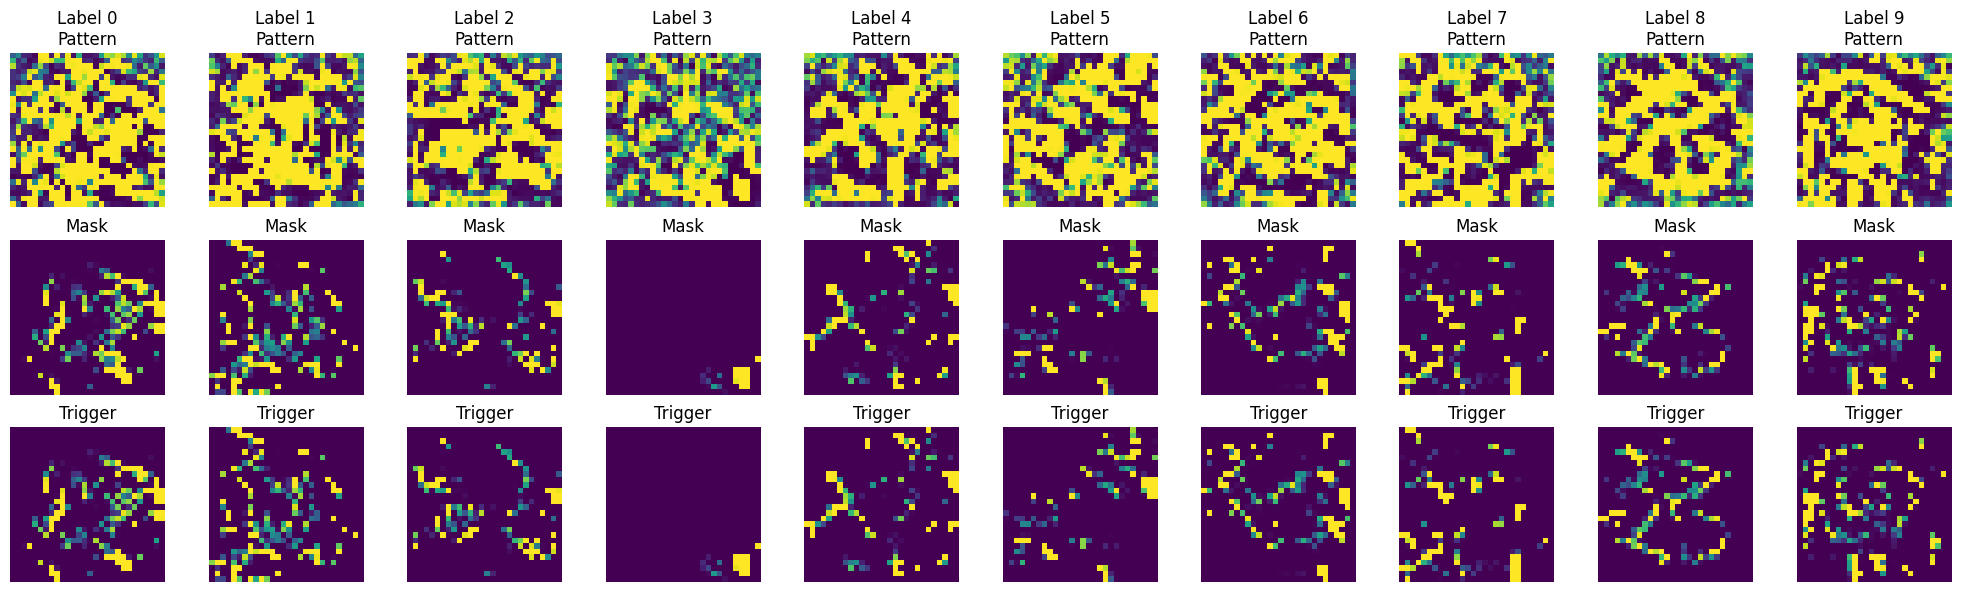

In [8]:
if target_label is not None:
    # 可视化 10 个类的逆向触发器
    fig, axes = plt.subplots(3, 10, figsize=(20, 6))

    for i in range(10):
        # 取出第 i 个类的 pattern 和 mask，并去掉通道维度变为 (28, 28)
        pattern = patterns[i][0]
        mask = masks[i][0]
        trigger = pattern * mask

        # 第一行：Pattern
        axes[0, i].imshow(pattern)  # 默认 cmap，和 Task 1 保持一致
        axes[0, i].set_title(f"Label {i}\nPattern")
        axes[0, i].axis("off")

        # 第二行：Mask
        axes[1, i].imshow(mask)
        axes[1, i].set_title("Mask")
        axes[1, i].axis("off")

        # 第三行：Trigger
        axes[2, i].imshow(trigger)
        axes[2, i].set_title("Trigger")
        axes[2, i].axis("off")

    plt.tight_layout()
    plt.show()

## 6. 评估逆向触发器的ASR
用逆向工程找出的掩码和模式生成中毒测试集，并测试攻击成功率。

In [9]:
def add_reverse_trigger(clean_data, pattern, mask):
    xs = []
    ys = []
    for x, y in clean_data:
        x_adv = (1 - mask) * x.numpy() + mask * pattern
        xs.append(torch.tensor(x_adv))
        ys.append(target_label)
    xs_tensor = torch.stack(xs)
    ys_tensor = torch.tensor(ys)
    return TensorDataset(xs_tensor, ys_tensor)

if target_label is not None:
    reverse_attack_test_data = add_reverse_trigger(clean_test_data, patterns[target_label], masks[target_label])
    reverse_attack_test_loader = DataLoader(dataset=reverse_attack_test_data, batch_size=batch_size, shuffle=False)
    
    asr = test(model, reverse_attack_test_loader, device)
    print(f"ASR of the reverse trigger: {asr:.2f}%")


ASR of the reverse trigger: 99.59%


## 7. 继续训练
使用10%干净训练集微调带有后门的模型，检查后门是否出现灾难性遗忘。

In [10]:
print("Continuing training on 10% clean set...")
model_ct = LeNet5().to(device)
model_ct.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
optimizer_ct = optim.Adam(model_ct.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

for epoch in range(epochs):
    train_loss = train(model_ct, clean_train_loader_batch, criterion, optimizer_ct, device)
    acc = test(model_ct, clean_test_loader, device)
    asr = test(model_ct, attack_test_loader, device)
    print(f"Epoch {epoch}: loss {train_loss:.4f}, ACC {acc:.2f}%, ASR {asr:.2f}%")


Continuing training on 10% clean set...
Epoch 0: loss 0.0521, ACC 98.22%, ASR 100.00%
Epoch 1: loss 0.0240, ACC 98.52%, ASR 99.99%
Epoch 2: loss 0.0267, ACC 98.05%, ASR 99.94%
Epoch 3: loss 0.0140, ACC 98.35%, ASR 99.96%
Epoch 4: loss 0.0074, ACC 98.45%, ASR 99.91%
Epoch 5: loss 0.0146, ACC 98.37%, ASR 99.90%
Epoch 6: loss 0.0167, ACC 97.64%, ASR 99.98%
Epoch 7: loss 0.0550, ACC 97.79%, ASR 96.88%
Epoch 8: loss 0.0603, ACC 97.67%, ASR 99.49%
Epoch 9: loss 0.0088, ACC 98.21%, ASR 99.61%


## 8. 后门修复
将干净样本中的20%添加逆向触发器（保持原标签），重新微调模型以消除后门威胁。

In [ ]:
print("Backdoor mitigation on 10% clean set...")
model_mitigate = LeNet5().to(device)
model_mitigate.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
optimizer_mitigate = optim.Adam(model_mitigate.parameters(), lr=lr)

def mitigate_dataset(clean_subset, pattern, mask, ratio=0.2):
    xs = []
    ys = []
    for x, y in clean_subset:
        if random.random() < ratio:
            x_adv = (1 - mask) * x.numpy() + mask * pattern # 生成带有逆向触发器的对抗样本
            xs.append(torch.tensor(x_adv, dtype=torch.float32))
        else:
            xs.append(x.clone())
        ys.append(y)
    xs_tensor = torch.stack(xs)
    ys_tensor = torch.tensor(ys)
    return TensorDataset(xs_tensor, ys_tensor)

if target_label is not None:
    mitigate_train_data = mitigate_dataset(clean_train_subset, patterns[target_label], masks[target_label], ratio=0.2)
    mitigate_train_loader = DataLoader(dataset=mitigate_train_data, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        train_loss = train(model_mitigate, mitigate_train_loader, criterion, optimizer_mitigate, device)
        acc = test(model_mitigate, clean_test_loader, device)
        asr = test(model_mitigate, attack_test_loader, device)
        print(f"Epoch {epoch}: loss {train_loss:.4f}, ACC {acc:.2f}%, ASR {asr:.2f}%")


Backdoor mitigation on 10% clean set...
Epoch 0: loss 1.3240, ACC 98.02%, ASR 10.45%
Epoch 1: loss 0.0461, ACC 98.14%, ASR 10.51%
Epoch 2: loss 0.0215, ACC 98.32%, ASR 10.40%
Epoch 3: loss 0.0162, ACC 98.34%, ASR 10.90%
Epoch 4: loss 0.0089, ACC 98.60%, ASR 10.68%
Epoch 5: loss 0.0035, ACC 98.56%, ASR 10.53%
Epoch 6: loss 0.0036, ACC 98.60%, ASR 10.70%
Epoch 7: loss 0.0019, ACC 98.61%, ASR 10.53%
Epoch 8: loss 0.0029, ACC 98.48%, ASR 10.57%
Epoch 9: loss 0.0077, ACC 98.24%, ASR 10.70%
